In [ ]:
from scipy.signal import chirp
import numpy as np
import matplotlib.pyplot as plt

from optic.dsp.core import firFilter, signal_power, pulseShape, upsample

### Exemplo 1 - Taxa de amostragem
---

In [ ]:
def sincInterp(x, fa):

    fa_sinc = 32*fa
    Ta_sinc = 1/fa_sinc
    Ta = 1/fa
    t = np.arange(0, x.size*32)*Ta_sinc

    y = upsample(x,32)
    y[y==0] = np.nan

    x_sum = 0
    for k in range(0, x.size):
        xk_interp = x[k]*np.sinc((t-k*Ta)/Ta)
        x_sum += xk_interp

    return x_sum, t

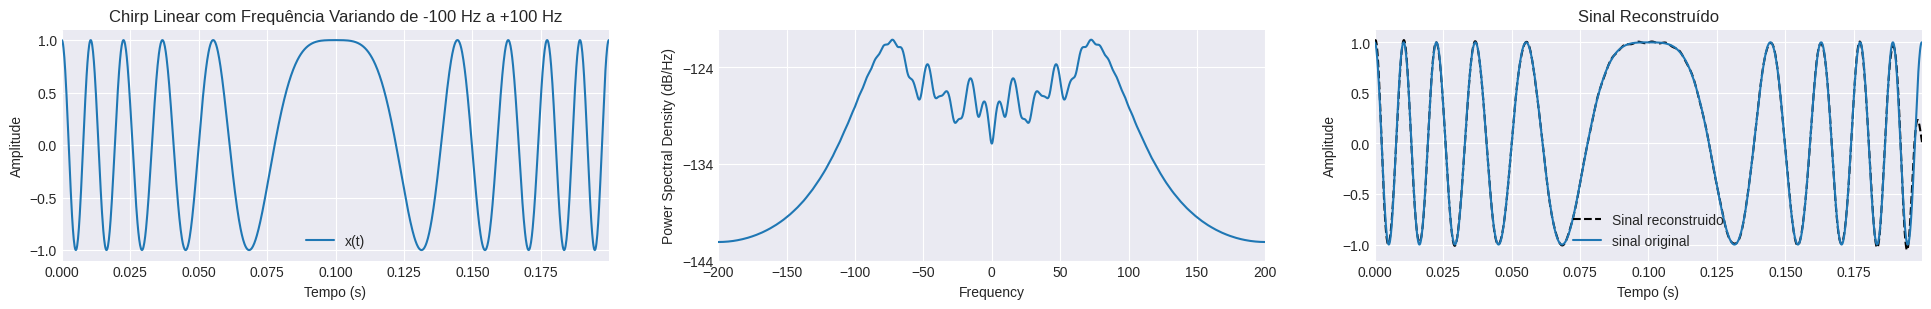

In [ ]:
Fa = 400    #frequencia de amostragem
Ta = 1/Fa   # taxa de amostragem
B = 100     # Intervalo do espectro na frequencia

t = np.arange(0, 0.2,Ta/16)     #duração do sinal
d = t.size/2                    #deixa o sinal simetrico
x = chirp(t, f0=-100, f1=100, t1=max(t), method='linear') #criando o sinal

# Realizando a amostragem do sinal
xa = x[::16]
ta = t[::16]

# Plot do sinal
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 3 , figsize=(24,3))
axis[0].plot(t, x, label="x(t)")
axis[0].set_title("Chirp Linear com Frequência Variando de -100 Hz a +100 Hz")
axis[0].set_xlabel("Tempo (s)")
axis[0].set_ylabel("Amplitude")
axis[0].set_xlim(min(t), max(t))
axis[0].legend(loc='best')

# plota psd
axis[1].psd(xa, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[1].set_xlim(-Fa/2, Fa/2)

x_int, t_int = sincInterp(xa, Fa)

axis[2].plot(t_int, x_int, "--k", label="Sinal reconstruido")
axis[2].set_title("Sinal Reconstruído")
axis[2].plot(t,x, label="sinal original")
axis[2].set_xlim(min(t), max(t))
axis[2].set_xlabel("Tempo (s)")
axis[2].set_ylabel("Amplitude")
axis[2].legend(loc='best')

plt.show()